# Week 5: AI-Assisted Triage: Data Exploration (Part 1 of 2)

This notebook uses the **Yale EMMLC triage extract** dataset (a de-identified arrivals dataset)

## 1. Setup

In [1]:
# Run this cell first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Let pandas show more of a wide table when printing
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

# All figures produced in this notebook are saved here.
Path("figs").mkdir(exist_ok=True)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


## 2. Load data

In [2]:
DATA_PATH = Path("yaleemmlc_admissionprediction_triage.csv")

df = pd.read_csv(DATA_PATH, index_col=0)   # index_col=0 drops the unnamed export index
print(f"Loaded real dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

df.head()

Loaded real dataset: 55,121 rows x 225 columns


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Shape and structural overview

Chief-complaint flags (`cc_*`) are complete-by-design 0/1 indicators, not free-standing measurements, so we separate them from the **structured** clinical/demographic columns before profiling missingness and types. Otherwise approximately 200 always-populated flag columns would drown out the columns that actually have gaps.

In [3]:
structured = [c for c in df.columns if not c.startswith("cc_")]
cc_flags   = [c for c in df.columns if c.startswith("cc_")]

print("Shape:", df.shape)
print(f"Structured columns: {len(structured)}   Chief-complaint flags: {len(cc_flags)}\n")
print("Column types at a glance:")
print(df.dtypes.value_counts())

Shape: (55121, 225)
Structured columns: 25   Chief-complaint flags: 200

Column types at a glance:
float64    210
object      15
Name: count, dtype: int64


**CLINICAL CONTEXT:** This is a **wide, sparse** dataset: most columns describe a single encounter thinly (one chief-complaint flag fires per patient), while a small core of demographic and vital-sign columns carries most of the analytical weight. Structural summaries below focus on that structured core.

## 4. `.info()` - Structural snapshot

In [4]:
df[structured].info()

<class 'pandas.core.frame.DataFrame'>
Index: 55121 entries, 7 to 433332
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dep_name                55121 non-null  object 
 1   esi                     55121 non-null  float64
 2   age                     55121 non-null  float64
 3   gender                  55121 non-null  object 
 4   ethnicity               55121 non-null  object 
 5   race                    55121 non-null  object 
 6   lang                    55121 non-null  object 
 7   religion                55121 non-null  object 
 8   maritalstatus           55121 non-null  object 
 9   employstatus            55121 non-null  object 
 10  insurance_status        55121 non-null  object 
 11  disposition             55121 non-null  object 
 12  arrivalmode             55121 non-null  object 
 13  arrivalmonth            55121 non-null  object 
 14  arrivalday              55121 non-null  ob

`.info()` gives, per column: its dtype and its count of **non-null** values. So, any column whose non-null count is below the total row count already flags itself as incomplete here.

## 5. `.describe()` - Numeric and categorical summaries

In [6]:
numeric_cols = df[structured].select_dtypes(include="number").columns.tolist()
print("Numeric columns:")
df[numeric_cols].describe().round(2)

Numeric columns:


,esi,age,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose
count,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00
mean,2.88,55.32,86.45,133.68,79.53,17.84,97.02,0.07,98.09,130.09
std,0.75,19.54,16.96,22.65,14.59,2.07,2.08,0.25,0.81,73.66
min,1.00,18.00,32.00,53.00,27.00,8.00,62.00,0.00,91.50,16.00
25%,2.00,40.00,74.00,118.00,70.00,16.00,96.00,0.00,97.70,93.00
50%,3.00,55.00,85.00,132.00,79.00,18.00,98.00,0.00,98.00,107.00
75%,3.00,70.00,97.00,147.00,89.00,18.00,98.00,0.00,98.40,134.00
max,5.00,107.00,221.00,266.00,189.00,66.00,99.00,1.00,106.00,1066.00


In [7]:
cat_cols = [c for c in structured if c not in numeric_cols]
print("Categorical / text columns:")
df[cat_cols].describe()

Categorical / text columns:


,dep_name,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo
count,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121
unique,3,2,4,8,2,12,10,10,5,2,7,12,7,6,10
top,A,Female,Non-Hispanic,White or Caucasian,English,Catholic,Single,Retired,Medicaid,Discharge,Car,June,Monday,11-14,Discharge
freq,34933,31744,45142,29435,50264,23550,22901,17058,21427,34565,22797,5987,8687,15872,28627


For categorical columns, `.describe()` reports `count` (non-null rows), `unique` (distinct categories), and the most frequent category with its frequency (`top` / `freq`), the categorical equivalent of mean/median for a number column.

## 6. Missing values

**ANALYTICAL NOTE:** A raw count of missing cells is hard to interpret on its own. Reporting **both** the count and the percentage keeps the audit honest and comparable across datasets.

In [8]:
missing_count = df[structured].isna().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct":   missing_pct,
    "dtype":         df[structured].dtypes.astype(str),
})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print(f"{len(missing_report)} of {len(structured)} structured columns have at least one missing value.\n")
missing_report

0 of 25 structured columns have at least one missing value.



,missing_count,missing_pct,dtype


## 7. Data type audit

Two failure modes matter here: a column that **should** be numeric but was read as text (often because of a stray unit suffix or a free-text placeholder like "NR"), and a column that **is** numeric but actually encodes a small set of categories (a code, not a quantity). Both silently break downstream statistics and models if left unflagged.

In [9]:
audit_rows = []

# (a) object/text columns that are mostly parseable as numbers
for col in structured:
    if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
        non_null = df[col].dropna()
        if len(non_null) == 0:
            continue
        parse_rate = pd.to_numeric(non_null, errors="coerce").notna().mean()
        if parse_rate > 0.9:
            audit_rows.append({
                "column": col, "current_dtype": "object",
                "issue": "numeric stored as text",
                "parseable_pct": round(parse_rate * 100, 1),
                "unique_values": np.nan,
            })

# (b) numeric columns with very few distinct values -> behaves like a category, not a quantity
for col in structured:
    if pd.api.types.is_numeric_dtype(df[col]):
        nun = df[col].nunique(dropna=True)
        if nun <= 5:
            audit_rows.append({
                "column": col, "current_dtype": str(df[col].dtype),
                "issue": "numeric but behaves like a category",
                "parseable_pct": np.nan,
                "unique_values": nun,
            })

dtype_audit = pd.DataFrame(audit_rows)
dtype_audit

,column,current_dtype,issue,parseable_pct,unique_values
0,esi,float64,numeric but behaves like a category,NaN,5
1,triage_vital_o2_device,float64,numeric but behaves like a category,NaN,2


**CORRECTIONS APPLIED:** the audit above flags two columns that are numerically typed but behave like categories, not quantities: `esi` (an ordinal acuity code, 1-5) and `triage_vital_o2_device` (a small-cardinality device code, e.g. room air vs supplemental O2). Left as generic floats, both could silently get averaged or treated as continuous measurements downstream, which would not make clinical sense (there is no such thing as an ESI of 2.5 or 'half a nasal cannula'). We cast them explicitly below. Any object column found to be >90% numeric-parseable text is also converted to a true numeric dtype.

In [10]:
# Apply the corrections identified by the dtype audit above.

# esi is an ORDINAL code (1 = most urgent ... 5 = least urgent), not a continuous quantity, but we
# keep it as a nullable integer (not a bare category) so it still sorts/plots in the right order and
# can be used numerically in the correlation analysis later in this notebook.
df["esi"] = df["esi"].astype("Int64")

# triage_vital_o2_device is a small-cardinality device code (e.g. room air vs supplemental O2),
# not a measurement -- casting it to category stops it being summarised as if it were a vital sign.
if "triage_vital_o2_device" in df.columns:
    df["triage_vital_o2_device"] = df["triage_vital_o2_device"].astype("category")

# Any object column the audit found to be >90% numeric-parseable gets converted for real use downstream.
text_to_numeric = dtype_audit[dtype_audit["issue"] == "numeric stored as text"]
for _, row in text_to_numeric.iterrows():
    col = row["column"]
    df[col] = pd.to_numeric(df[col], errors="coerce")
    print(f"Converted {col} to numeric (was stored as text).")

# Target alias: the assignment brief calls the triage-acuity label 'Triage_Level'; in this dataset
# it is the Yale-EMMLC Emergency Severity Index ('esi'). We alias it here, after the dtype fix
# above, so every later section can refer to it by the assignment's name.
TARGET = "Triage_Level"
df[TARGET] = df["esi"]

print("\nCorrected dtypes:")
print(df[["esi", TARGET] + (["triage_vital_o2_device"] if "triage_vital_o2_device" in df.columns else [])].dtypes)
print("\nTriage_Level values present:", sorted(df[TARGET].dropna().unique().tolist()))


Corrected dtypes:
esi                          Int64
Triage_Level                 Int64
triage_vital_o2_device    category
dtype: object

Triage_Level values present: [1, 2, 3, 4, 5]


## 8. Missingness visualisation

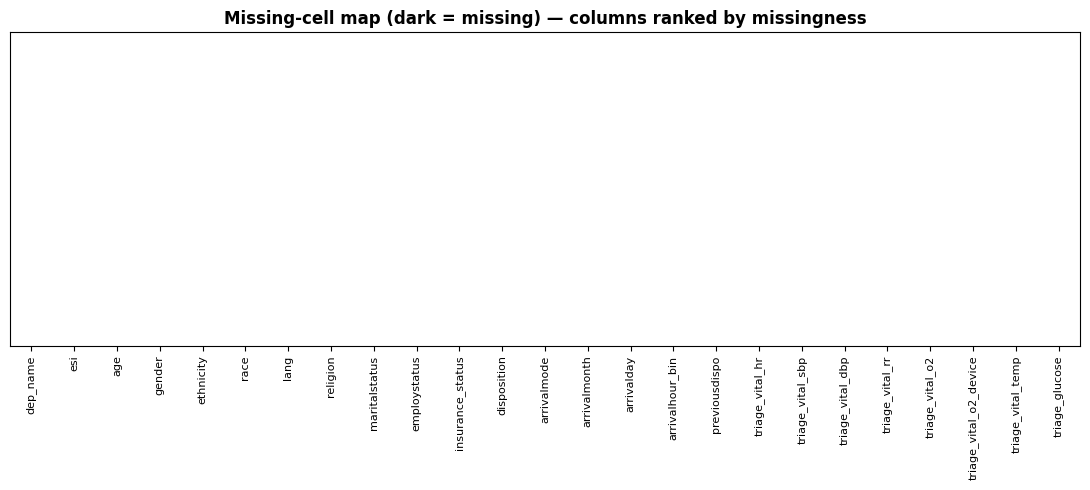

In [16]:
# Missing-cell map, columns ordered worst-missing first
ordered_cols = missing_report.index.tolist() + [c for c in structured if c not in missing_report.index]

try:
    import missingno as msno
    msno.matrix(df[ordered_cols])
    plt.title("Missing-cell map (columns ranked by missingness)")
    plt.tight_layout()
    plt.savefig("figs/missingness_matrix.png", dpi=150)
    plt.show()
except ImportError:
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(df[ordered_cols].isna().values, aspect="auto", cmap="gray_r", interpolation="nearest")
    ax.set_xticks(range(len(ordered_cols)))
    ax.set_xticklabels(ordered_cols, rotation=90, fontsize=8)
    ax.set_yticks([])
    ax.set_title("Missing-cell map (dark = missing) — columns ranked by missingness", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figs/missingness_matrix.png", dpi=150)
    plt.show()

## 9. Outlier Detection

**CLINICAL CONTEXT:** a vital sign can be *unusual* (statistically rare but physiologically real -- e.g. a very fit patient's resting pulse of 45 bpm) or *impossible* (a data-entry error -- e.g. a pulse of 3 bpm). We use two complementary, well-established methods plus a clinical sanity check:
- **1.5×IQR fence** -- a distribution-based, unit-agnostic flag for statistically rare values.
- **|z-score| > 3** -- flags values more than 3 standard deviations from the column mean.
- **Physiologically implausible bounds** -- hard limits a live human could not fall outside of (e.g. heart rate below 20 bpm or above 250 bpm), regardless of what the rest of the distribution looks like.

Values outside the plausible bounds should be treated as data errors, not as evidence of an extremely sick patient, and are candidates for correction or removal rather than modelling.

In [12]:
# Reference ("normal") ranges for adult ED triage vitals -- used for axis labels and shading below,
# not for flagging outliers. NOTE: temperature is recorded in FAHRENHEIT in this dataset.
NORMAL_RANGES = {
    "triage_vital_hr":   (60, 100, "bpm"),
    "triage_vital_sbp":  (90, 140, "mmHg"),
    "triage_vital_dbp":  (60, 90,  "mmHg"),
    "triage_vital_rr":   (12, 20,  "/min"),
    "triage_vital_o2":   (95, 100, "%"),
    "triage_vital_temp": (97.0, 99.5, "F"),
    "triage_glucose":    (70, 140, "mg/dL"),
}

# "Plausible" bounds are deliberately much wider than normal -- anything OUTSIDE these is a
# physiologically implausible value (almost certainly a data-entry error), not a very sick patient.
PLAUSIBLE = {
    "triage_vital_hr":   (20, 250),
    "triage_vital_sbp":  (50, 300),
    "triage_vital_dbp":  (20, 200),
    "triage_vital_rr":   (4, 60),
    "triage_vital_o2":   (50, 100),
    "triage_vital_temp": (86, 110),
    "triage_glucose":    (20, 800),
}

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

def outlier_report(series, plausible_bounds):
    """Count IQR outliers, |z|>3 outliers, and physiologically-implausible values in one numeric column."""
    x = pd.to_numeric(series, errors="coerce").dropna()

    # Method 1: 1.5 x IQR fence (distribution-based, robust to skew)
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    low_fence, high_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_outliers = int(((x < low_fence) | (x > high_fence)).sum())

    # Method 2: |z-score| > 3 (assumes a roughly-normal shape; sensitive to the mean/SD it is measured against)
    z = (x - x.mean()) / x.std()
    z_outliers = int((z.abs() > 3).sum())

    # Method 3: physiologically implausible (clinically impossible, regardless of distribution shape)
    low, high = plausible_bounds
    implausible = int(((x < low) | (x > high)).sum())

    n = len(x)
    return pd.Series({
        "n_values": n,
        "iqr_outliers": iqr_outliers,
        "iqr_outlier_pct": round(iqr_outliers / n * 100, 2),
        "zscore_outliers_|z|>3": z_outliers,
        "implausible_values": implausible,
        "implausible_pct": round(implausible / n * 100, 2),
    })

outlier_summary = pd.DataFrame({col: outlier_report(df[col], PLAUSIBLE[col]) for col in VITALS}).T
outlier_summary

,n_values,iqr_outliers,iqr_outlier_pct,zscore_outliers_|z|>3,implausible_values,implausible_pct
triage_vital_hr,55121.0,578.0,1.05,326.0,0.0,0.00
triage_vital_sbp,55121.0,1028.0,1.86,434.0,0.0,0.00
triage_vital_dbp,55121.0,726.0,1.32,325.0,0.0,0.00
triage_vital_rr,55121.0,2366.0,4.29,514.0,4.0,0.01
triage_vital_o2,55121.0,1505.0,2.73,706.0,0.0,0.00
triage_vital_temp,55121.0,3554.0,6.45,858.0,0.0,0.00
triage_glucose,55121.0,5673.0,10.29,1363.0,25.0,0.05


**ANALYTICAL NOTE:** the table above answers *how many* implausible values exist per vital; the chart below answers *which vitals are the biggest data-quality risk*, so cleaning effort can be targeted rather than applied uniformly.

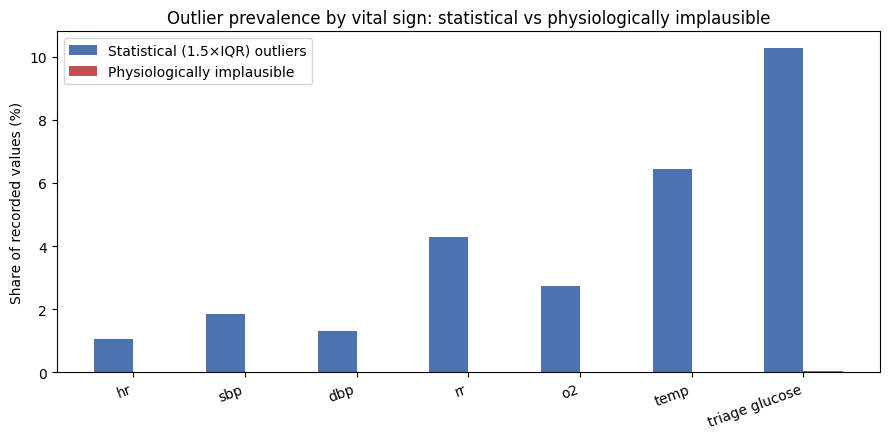

In [13]:
# Data-quality question: which vitals carry the most statistically-rare vs physiologically-impossible values?
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(VITALS))
width = 0.35

ax.bar(x - width/2, outlier_summary["iqr_outlier_pct"], width, label="Statistical (1.5×IQR) outliers", color="#4C72B0")
ax.bar(x + width/2, outlier_summary["implausible_pct"], width, label="Physiologically implausible", color="#C44E52")

ax.set_xticks(x)
ax.set_xticklabels([c.replace("triage_vital_", "").replace("_", " ") for c in VITALS], rotation=20, ha="right")
ax.set_ylabel("Share of recorded values (%)")
ax.set_title("Outlier prevalence by vital sign: statistical vs physiologically implausible")
ax.legend()
plt.tight_layout()
plt.savefig("figs/outlier_prevalence_by_vital.png", dpi=150)
plt.show()

## 10. Distribution analysis of key features

**CLINICAL CONTEXT:** before comparing vitals across triage groups, we look at each one's overall shape on its own: is it roughly symmetric (mean and median close together), skewed (e.g. glucose, which typically has a long right tail from hyperglycaemic patients), or multi-modal? This shapes which summary statistic to trust (mean vs median) and whether a transformation would be needed before modelling. The shaded band on each panel marks the textbook-normal range for that vital, purely as a visual reference. It is not a cleaning threshold.

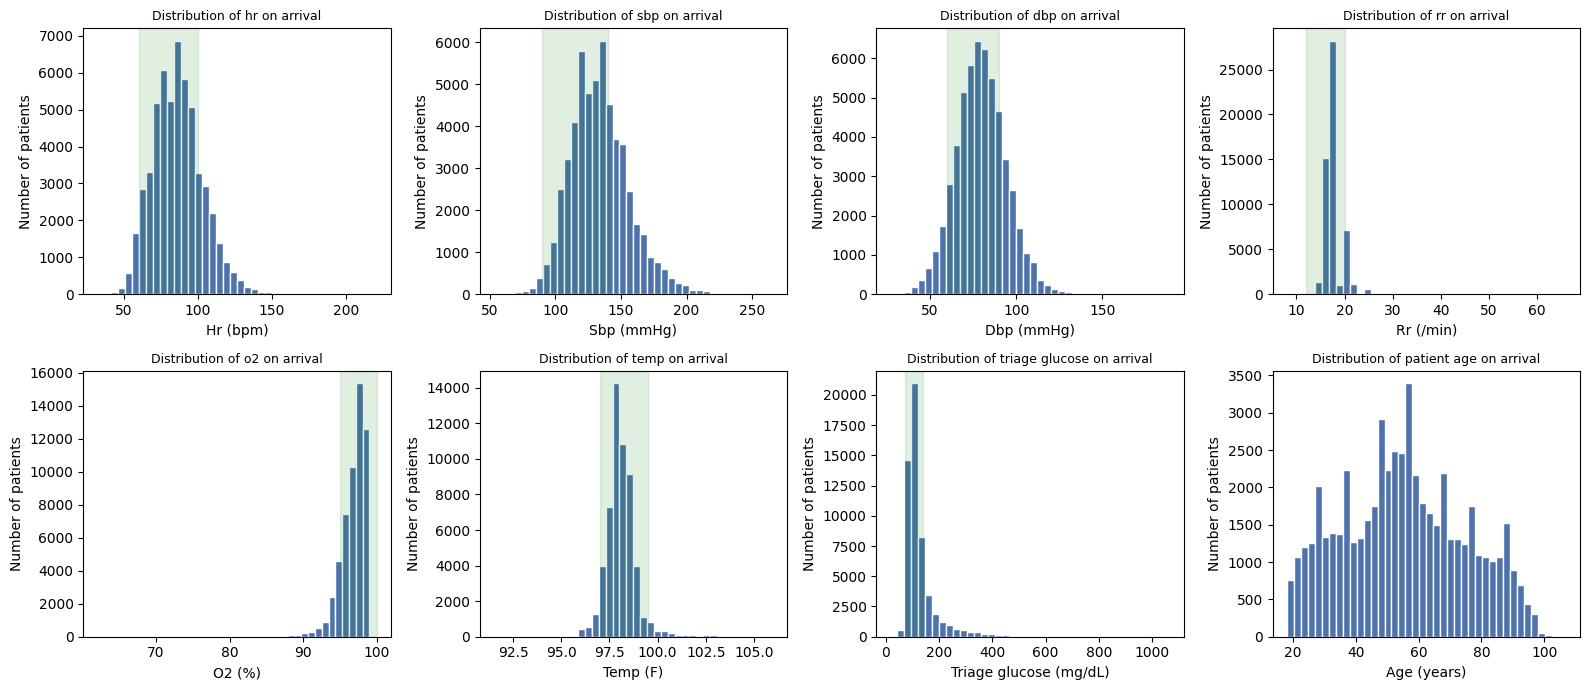

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
panels = axes.ravel()

for panel, col in zip(panels, VITALS):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    low, high, unit = NORMAL_RANGES[col]
    label = col.replace("triage_vital_", "").replace("_", " ")
    panel.hist(values, bins=40, color="#4C72B0", edgecolor="white")
    panel.axvspan(low, high, color="green", alpha=0.12, label="normal range")
    panel.set_title(f"Distribution of {label} on arrival", fontsize=9)
    panel.set_xlabel(f"{label.capitalize()} ({unit})")
    panel.set_ylabel("Number of patients")

# Age fills the 8th panel of the 2x4 grid (7 vitals + age).
age = pd.to_numeric(df["age"], errors="coerce").dropna()
panels[-1].hist(age, bins=40, color="#4C72B0", edgecolor="white")
panels[-1].set_title("Distribution of patient age on arrival", fontsize=9)
panels[-1].set_xlabel("Age (years)")
panels[-1].set_ylabel("Number of patients")

plt.tight_layout()
plt.savefig("figs/distributions_vitals_age.png", dpi=150)
plt.show()

## 11. Triage_Level (ESI) distribution

**CLINICAL CONTEXT:** `Triage_Level` (ESI) is the acuity label assigned at the front door: 1 = most urgent (resuscitation) through 5 = least urgent (non-urgent). Its class balance matters for any downstream model: if one level dominates the sample, a classifier can score well overall by defaulting to the majority class while still missing the rare, most-urgent patients that matter most clinically.

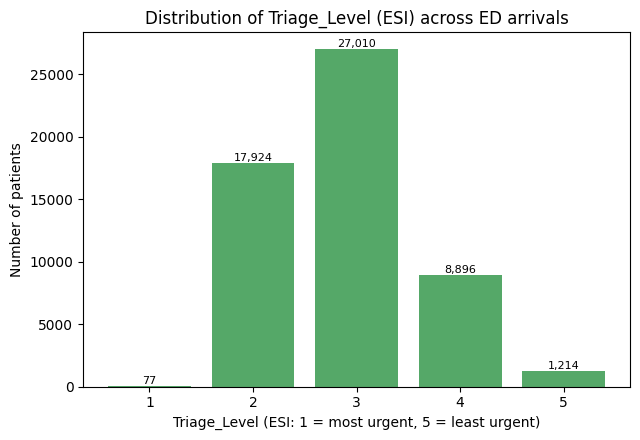

Share of arrivals by Triage_Level (%):
Triage_Level
1     0.1
2    32.5
3    49.0
4    16.1
5     2.2
Name: count, dtype: Float64


In [19]:
triage_counts = df[TARGET].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(triage_counts.index.astype(str), triage_counts.values, color="#55A868")
ax.set_title("Distribution of Triage_Level (ESI) across ED arrivals")
ax.set_xlabel("Triage_Level (ESI: 1 = most urgent, 5 = least urgent)")
ax.set_ylabel("Number of patients")
for bar, v in zip(bars, triage_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("figs/triage_level_distribution.png", dpi=150)
plt.show()

print("Share of arrivals by Triage_Level (%):")
print((triage_counts / triage_counts.sum() * 100).round(1))

## 12. Vital signs by Triage_Level

**CLINICAL CONTEXT:** if triage is behaving as a physiological signal (and not purely a clerical judgement), the sicker patients (low `Triage_Level`) should show more deranged vitals. Comparing each vital's spread *across* Triage_Level groups is a direct check of that assumption, and shows which single vital is the strongest acuity signal on its own, useful context before any multivariate model is built.

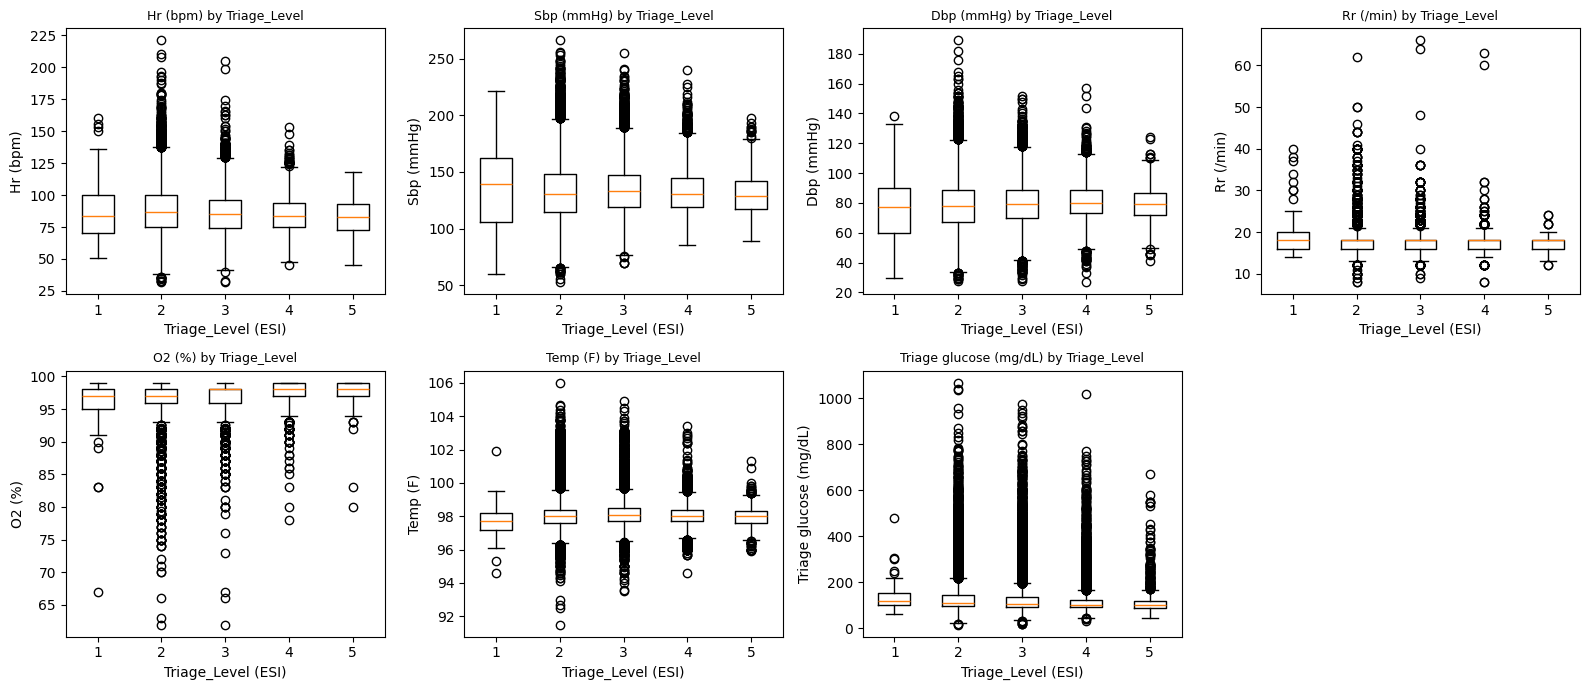

In [20]:
triage_levels = sorted(df[TARGET].dropna().unique().tolist())

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
panels = axes.ravel()

for panel, col in zip(panels, VITALS):
    groups = [pd.to_numeric(df.loc[df[TARGET] == level, col], errors="coerce").dropna()
              for level in triage_levels]
    low, high, unit = NORMAL_RANGES[col]
    label = col.replace("triage_vital_", "").replace("_", " ")
    panel.boxplot(groups, tick_labels=[str(int(l)) for l in triage_levels])
    panel.set_title(f"{label.capitalize()} ({unit}) by Triage_Level", fontsize=9)
    panel.set_xlabel("Triage_Level (ESI)")
    panel.set_ylabel(f"{label.capitalize()} ({unit})")

panels[-1].axis("off")  # 7 vitals in an 8-panel grid; the spare panel is left blank
plt.tight_layout()
plt.savefig("figs/vitals_by_triage_level.png", dpi=150)
plt.show()

## 13. Correlation analysis with Triage_Level

**ANALYTICAL NOTE:** correlation here is a directional sanity check, not a causal claim and not a model. `Triage_Level` runs 1 (most urgent) to 5 (least urgent), so a **negative** correlation between a vital and `Triage_Level` means that vital tends to be *higher* when urgency is *higher* (lower Triage_Level) -- the sign takes a moment to get used to.

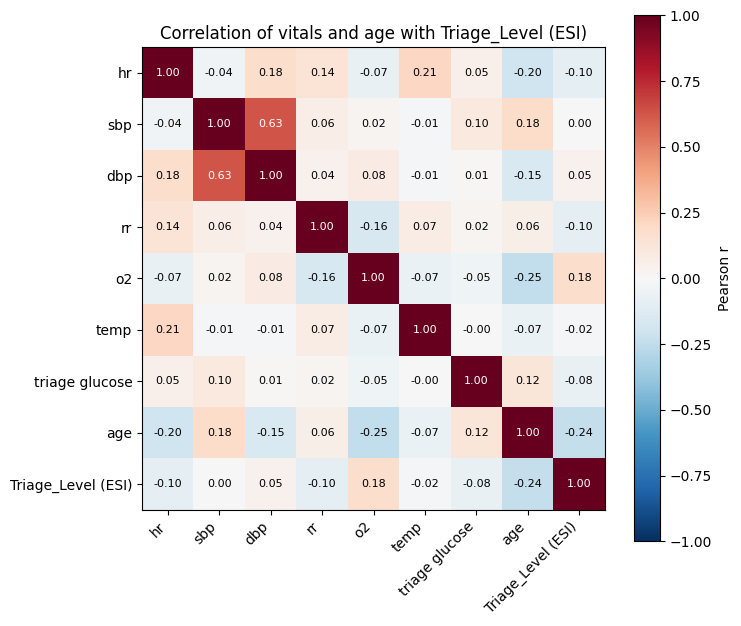

Vitals ranked by strength of correlation with Triage_Level:
age                 -0.237
triage_vital_o2      0.178
triage_vital_rr     -0.095
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_dbp     0.046
triage_vital_temp   -0.022
triage_vital_sbp     0.001
Name: Triage_Level, dtype: float64


In [21]:
corr_cols = VITALS + ["age", TARGET]
corr = df[corr_cols].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

labels = [c.replace("triage_vital_", "").replace("_", " ") for c in corr_cols[:-1]] + ["Triage_Level (ESI)"]
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(labels)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.5 else "black")

ax.set_title("Correlation of vitals and age with Triage_Level (ESI)")
fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.savefig("figs/correlation_heatmap.png", dpi=150)
plt.show()

print("Vitals ranked by strength of correlation with Triage_Level:")
print(corr[TARGET].drop(TARGET).reindex(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).index).round(3))

**CLINICAL CONTEXT:** the vital(s) with the largest absolute correlation to `Triage_Level` are the strongest *single-variable* acuity signals in this dataset; the rest most likely add value mainly in combination with each other (e.g. inside a multivariate model) rather than alone, and near-zero correlations should not be read as "clinically irrelevant", only as "not linearly related to acuity on their own".

## 14. Data-quality summary

In [22]:
issues = []
for col, row in missing_report.iterrows():
    severity = "high" if row["missing_pct"] >= 25 else ("moderate" if row["missing_pct"] >= 10 else "low")
    issues.append({
        "column": col,
        "missing_pct": row["missing_pct"],
        "severity": severity,
        "suggested_action": "review for drop / imputation strategy" if severity != "low" else "monitor",
    })
for _, r in dtype_audit.iterrows():
    issues.append({
        "column": r["column"],
        "missing_pct": np.nan,
        "severity": "dtype",
        "suggested_action": r["issue"],
    })

# Fold the outlier / implausible-value findings from Section 9 into the same table.
for col, row in outlier_summary.iterrows():
    if row["implausible_pct"] > 0:
        issues.append({
            "column": col,
            "missing_pct": np.nan,
            "severity": "high" if row["implausible_pct"] >= 1 else "moderate",
            "suggested_action": f"{row['implausible_pct']}% physiologically implausible -- recode as missing, do not impute as-is",
        })
    elif row["iqr_outlier_pct"] >= 5:
        issues.append({
            "column": col,
            "missing_pct": np.nan,
            "severity": "moderate",
            "suggested_action": f"{row['iqr_outlier_pct']}% statistical outliers -- review, likely genuine extreme values",
        })

quality_summary = pd.DataFrame(issues)
quality_summary

,column,missing_pct,severity,suggested_action
0,esi,NaN,dtype,numeric but behaves like a category
1,triage_vital_o2_device,NaN,dtype,numeric but behaves like a category
2,triage_vital_rr,NaN,moderate,0.01% physiologically implausible -- recode as...
3,triage_vital_temp,NaN,moderate,"6.45% statistical outliers -- review, likely g..."
4,triage_glucose,NaN,moderate,0.05% physiologically implausible -- recode as...


## 15. Wrap-up

This notebook has measured: shape and dtypes, descriptive statistics, per-column missingness (counts and percentages), a dtype-inconsistency audit with corrections applied, outlier detection (1.5×IQR, |z|>3, and physiologically implausible bounds), distribution analysis of the key vitals and age, the `Triage_Level` (ESI) class balance, vital-sign spread across Triage_Level groups, and a correlation analysis of vitals and age against `Triage_Level`. Five figures were exported to `figs/`: the missingness map, the outlier-prevalence chart, the vitals/age distributions, the `Triage_Level` distribution, the vitals-by-`Triage_Level` box plots, and the correlation heatmap.